In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from keras.layers import Dense
from keras.models import Sequential


2026-03-31 03:24:47.870519: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774927488.177952      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774927488.266858      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774927488.975947      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774927488.976015      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774927488.976018      55 computation_placer.cc:177] computation placer alr

In [4]:
X,y=make_moons(n_samples=250,noise=0.05,random_state=42)

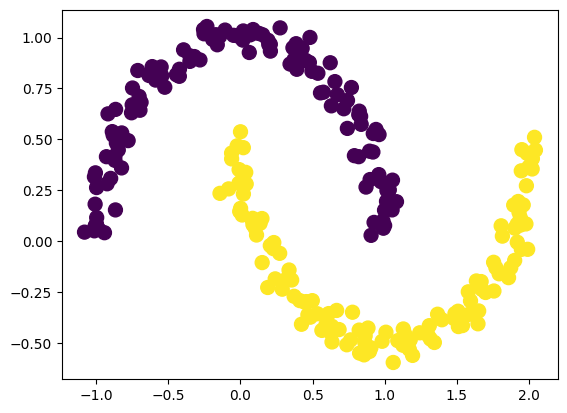

In [5]:
plt.scatter(X[:,0],X[:,1],c=y,s=100)

In [6]:
model=Sequential()
model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-31 03:29:40.232886: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [13]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [14]:
old_weights=model.get_weights()[0]

In [15]:
old_weights


array([[ 0.00647664,  0.34261328, -0.05564648,  0.12620336, -0.09061116,
        -0.47363698, -0.12967509,  0.44724125,  0.67793554,  0.25030035],
       [-0.03463274,  0.37763828,  0.10744244, -0.26704952, -0.18307441,
         0.0470649 , -0.00495058, -0.3834881 , -0.5687233 ,  0.52200574]],
      dtype=float32)

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
model.fit(X_train,y_train,epochs=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.0000e+00 - loss: 2.7049


In [18]:
new_weights=model.get_weights()[0]

In [19]:
new_weights

array([[ 0.00648869,  0.34263027, -0.05565016,  0.12621544, -0.09056462,
        -0.473632  , -0.12967321,  0.44723484,  0.67791855,  0.25028765],
       [-0.03460965,  0.37764257,  0.10739443, -0.26703787, -0.18307997,
         0.04702624, -0.00492973, -0.3835323 , -0.56877685,  0.5220252 ]],
      dtype=float32)

In [21]:
model.optimizer.get_config()['learning_rate']
# gradient=(old_weights-new_weights)/0.0010
# percentage_chage=abs(100*(old_weights-new_weights)/old_weights)

0.0010000000474974513

In [22]:
gradient=(old_weights-new_weights)/0.0010#(here gradient that is chage in delta l by delta weight)

In [23]:
percentage_chage=abs(100*(old_weights-new_weights)/old_weights)

In [24]:
gradient

array([[-0.01204479, -0.01698732,  0.00368431, -0.01208484, -0.04653632,
        -0.00497699, -0.00187755,  0.0064075 ,  0.01698732,  0.01269579],
       [-0.0230968 , -0.00429153,  0.04800409, -0.01165271,  0.00555813,
         0.03865734, -0.0208551 ,  0.04419684,  0.05352497, -0.01949072]],
      dtype=float32)

In [25]:
percentage_chage

array([[0.18597287, 0.00495816, 0.00662093, 0.00957569, 0.05135827,
        0.0010508 , 0.00144789, 0.00143267, 0.00250574, 0.00507222],
       [0.06669065, 0.00113641, 0.04467889, 0.0043635 , 0.003036  ,
        0.08213624, 0.42126566, 0.01152496, 0.00941143, 0.00373381]],
      dtype=float32)

In [26]:
#doing same for more epochs
model=Sequential()
model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))

In [27]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [28]:
old_weights=model.get_weights()[0]

In [29]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [30]:
model.fit(X_train,y_train,epochs=100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.0000e+00 - loss: 2.3572
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0000e+00 - loss: 2.2796 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0000e+00 - loss: 2.1967 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: 2.1171 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0757 - loss: 2.0396     
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4636 - loss: 1.9637 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4933 - loss: 1.8880 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4826 - loss: 1.8158 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4642 - loss: 1.7456 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4892 - loss: 1.6767 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5124 - loss: 1.6110 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - ac

In [31]:
new_weights=model.get_weights()[0]

In [32]:
old_weights

array([[-0.60416967, -0.14529651,  0.4845112 ,  0.3799351 , -0.14251482,
         0.48966902,  0.11852705,  0.5993561 ,  0.05520529, -0.6271523 ],
       [-0.27425846, -0.29920232,  0.17981833,  0.1389187 ,  0.2595607 ,
        -0.32184413,  0.08196497, -0.42048916, -0.558774  ,  0.46064335]],
      dtype=float32)

In [33]:
new_weights

array([[-0.60528195, -0.14557795,  0.48104677,  0.37895718, -0.13876964,
         0.49422216,  0.11135611,  0.6039021 ,  0.05885581, -0.62588614],
       [-0.2696982 , -0.3035319 ,  0.19635542,  0.13378379,  0.25557265,
        -0.31836537,  0.06973463, -0.41079757, -0.56901616,  0.46780938]],
      dtype=float32)

In [34]:
# #even after 100 epoch very small change in weights
# hence this is vanishing gradient problem due to sigmoid activation function

In [35]:
#now we will reduce complexity of model
model=Sequential()
model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))
model.add(Dense(10,activation='sigmoid',))

model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
old_weights=model.get_weights()[0]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model.fit(X_train,y_train,epochs=100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0000e+00 - loss: 2.2648
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0000e+00 - loss: 2.1804 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: 2.0922 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0452 - loss: 2.0118     
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4962 - loss: 1.9292 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5105 - loss: 1.8500 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4807 - loss: 1.7747 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4671 - loss: 1.7017 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4774 - loss: 1.6302 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4746 - loss: 1.5612 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4694 - loss: 1.4955 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accurac

In [37]:
#here accuracy increased
#also little updates are seen in weights
old_weights
# new_weights


array([[-0.66718125, -0.44363976,  0.43014258, -0.42190275,  0.19635338,
         0.4086284 , -0.02965522,  0.08614105,  0.45027202,  0.4866342 ],
       [ 0.36898857,  0.46603745, -0.6027158 ,  0.59679705,  0.40916866,
         0.6810095 , -0.5050983 ,  0.1641087 , -0.6856571 ,  0.45780462]],
      dtype=float32)

In [38]:
new_weights

array([[-0.60528195, -0.14557795,  0.48104677,  0.37895718, -0.13876964,
         0.49422216,  0.11135611,  0.6039021 ,  0.05885581, -0.62588614],
       [-0.2696982 , -0.3035319 ,  0.19635542,  0.13378379,  0.25557265,
        -0.31836537,  0.06973463, -0.41079757, -0.56901616,  0.46780938]],
      dtype=float32)

In [39]:
#now using diffrent activation function ie relu
model=Sequential()
model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu',))
model.add(Dense(10,activation='relu',))
model.add(Dense(10,activation='relu',))
model.add(Dense(10,activation='relu',))
model.add(Dense(10,activation='relu',))
model.add(Dense(10,activation='relu',))
model.add(Dense(10,activation='relu',))
model.add(Dense(10,activation='relu',))
model.add(Dense(10,activation='relu',))
model.add(Dense(10,activation='sigmoid',))

model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
old_weights=model.get_weights()[0]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model.fit(X_train,y_train,epochs=100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3043 - loss: 2.3002    
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6224 - loss: 2.2821
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5490 - loss: 2.2621 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4808 - loss: 2.2385 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5050 - loss: 2.2065 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4996 - loss: 2.1616 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4987 - loss: 2.0942 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4649 - loss: 1.9981 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5262 - loss: 1.8461 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4914 - loss: 1.6410 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4908 - loss: 1.3674 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5089 - 

In [42]:
#accury increased higly
#high updates in weights
old_weights

array([[-0.5816661 , -0.17657828, -0.59181494,  0.3833775 ,  0.386025  ,
         0.22757596,  0.24525082, -0.60665023,  0.6943448 , -0.0181582 ],
       [-0.08060229,  0.43134385, -0.6187024 ,  0.2712084 ,  0.26394832,
         0.03966254,  0.57053846,  0.337488  , -0.30407804, -0.5155596 ]],
      dtype=float32)

In [43]:
new_weights

array([[-0.60528195, -0.14557795,  0.48104677,  0.37895718, -0.13876964,
         0.49422216,  0.11135611,  0.6039021 ,  0.05885581, -0.62588614],
       [-0.2696982 , -0.3035319 ,  0.19635542,  0.13378379,  0.25557265,
        -0.31836537,  0.06973463, -0.41079757, -0.56901616,  0.46780938]],
      dtype=float32)

In [44]:
model.optimizer.get_config()['learning_rate']
gradient=(old_weights-new_weights)/0.0010
percentage_chage=abs(100*(old_weights-new_weights)/old_weights)

In [45]:
model.optimizer.get_config()['learning_rate']

0.0010000000474974513

In [46]:
gradient

array([[   23.615835,   -31.00033 , -1072.8616  ,     4.42031 ,
          524.7946  ,  -266.64618 ,   133.8947  , -1210.5522  ,
          635.48895 ,   607.7279  ],
       [  189.0959  ,   734.87573 ,  -815.0578  ,   137.4246  ,
            8.375674,   358.0279  ,   500.8038  ,   748.2855  ,
          264.9381  ,  -983.36896 ]], dtype=float32)

In [47]:

percentage_chage

array([[4.0600333e+00, 1.7556139e+01, 1.8128329e+02, 1.1529917e+00,
        1.3594835e+02, 1.1716801e+02, 5.4595009e+01, 1.9954700e+02,
        9.1523544e+01, 3.3468516e+03],
       [2.3460365e+02, 1.7036888e+02, 1.3173665e+02, 5.0671227e+01,
        3.1732252e+00, 9.0268530e+02, 8.7777405e+01, 2.2172212e+02,
        8.7128334e+01, 1.9073817e+02]], dtype=float32)